
# Kernel Ridge Regression

In this tutorial, we will build our first kernel based machine learning model with
the in-built Kernel Ridge Regressor module. We will focus on a single fidelity KRR
model that predicts the excitation energies of the benzene molecule from the
dataset provided in this package.


## Loading the Built-in Dataset
Let's load the dataset and isolate only those
geometries which have the def2-TZVP fidelity
we will build a single fidelity KRR model to
predict these energies.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mfml_qc.datasets import load_benzene_data

dataset = load_benzene_data()

X = dataset["X_CM"]
y = dataset["energies"][
    :, 7
]  # Selecting TZVP (index 7; recall that index 0 is the time step)

# Filter out NaNs
mask = ~np.isnan(y)
X, y = X[mask], y[mask]

# we will follow the protocol in
# J. Chem. Theory Comput. 2023, 19, 21, 7658–7670 (10.1021/acs.jctc.3c00882)
# and set the last 2712 geometries/entries as the test set

X_train = X[:-2712]
y_train = y[:-2712]
X_test = X[-2712:]
y_test = y[-2712:]

/home/vvinod/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Learning Curve Generator Function
While training a model, it is worthwhile to also
consider how well the prediction error is on an
unseen test dataset. This assessment is made
with the help of a learning curve which plots
model complexity against the model prediction error.
For KRR, model complexity is directly related to the number of training samples.
Therefore we will look at the model prediction error (given as mean absolute error; MAE)
as a function of the nunmber of training samples used.
To get a statistical idea of the error, we will generate learning curves
for 10 random sub-sampling of the training dataset.



In [2]:
# import the inbuilt KRR module
from mfml_qc.krr import KRR
from sklearn.utils import shuffle


# let's create a learning curve helper function
def sf_LC(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    kernel_type: str = "matern",
    sigma: float = 100.0,
    reg: float = 1e-10,
    nu=1.5,
    p=1.5,
    q=1.0,
    navg: int = 10,
    nmax: int = 10,
    seed: int = 42,
) -> np.ndarray:
    """
    A simple learning curve generation function.

    Args:
        X_train (np.ndarray): training feature data.
        y_train (np.ndarray): training target data.
        X_test (np.ndarray): testing feature data.
        y_test (np.ndarray): testing target data.
        kernel_type (str, optional): kernel type. Defaults to 'matern'.
        sigma (float, optional): kernel width/sigma. Defaults to 100.0.
        reg (float, optional): regularization parameter. Defaults to 1e-10.
        nu (1.0, 1.5, or 2, optional): nu paraemter for matern kernels. Defaults to 1.5.
        p (float, optional): Wasserstein kernel parameter. Defaults to 1.5.
        1 (float, optional): Wasserstein kernel parameter, Defaults to 1.0.
        navg (int, optional): number of averaging loops/shuffles. Defaults to 10.
        nmax (int, optional): maximum training size (2^nmax). Defaults to 10.
        seed (int, optional): random state seed for reproducibility. Defaults to 42.

    Returns:
        full_maes (np.ndarray): array of shape (nmax, navg) containing Mean Absolute Errors.
    """

    full_maes = np.zeros((nmax, navg), dtype=float)
    # init the KRR model
    model = KRR(sigma=sigma, reg=reg, kernel_type=kernel_type)
    for n in range(navg):
        maes = []
        X_train_shuf, y_train_shuf = shuffle(X_train, y_train, random_state=seed + n)
        # training size loop
        for i in range(1, 1 + nmax):
            X_tr_subset = X_train_shuf[: 2**i]
            y_tr_subset = y_train_shuf[: 2**i]
            model.train(X_tr_subset, y_tr_subset)
            preds_test = model.predict(X_test)
            maes.append(np.mean(np.abs(preds_test - y_test)))
        full_maes[:, n] = np.asarray(maes)
    return full_maes

## The learning curve
get the maes



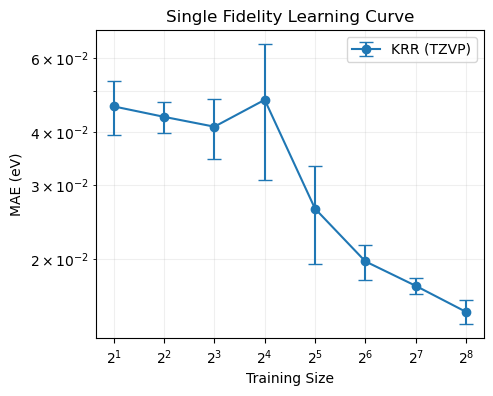

In [3]:
maes = sf_LC(
    X_train,
    y_train,
    X_test,
    y_test,
    reg=1e-9,
    sigma=715.0,
    kernel_type="matern",
    nu=1.5,
    navg=5,
    nmax=8,
)

# Plot the MAE vs training samples
mean_mae = np.mean(maes, axis=1)
std_mae = np.std(maes, axis=1)
train_sizes = [2**i for i in range(1, 9)]

plt.figure(figsize=(5, 4))
plt.errorbar(
    train_sizes, mean_mae, yerr=std_mae, fmt="o-", capsize=5, label="KRR (TZVP)"
)
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Training Size")
plt.ylabel("MAE (eV)")
plt.title("Single Fidelity Learning Curve")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()